<a href="https://colab.research.google.com/github/GusZelaya/TELECO1/blob/main/AM_Ejercicios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# **Telecomunicaciones 1**
## Resolución de ejercicios

S. Haykin, ``Communication Systems'', 4th. ed., 2001

**Autor:** Fernando Brunetti

**Fecha:** 20/01/2025

7. 9, 19

---
# **Ejercicios: Modulación en amplitud (AM)**

---
## **Ejercicio 2.1** [Dev, falta simulación]
**- Modulación AM**
<div>
<img src='https://drive.google.com/uc?id=1-3GDVVjlMjesOejYUUXIAk3Iggc5HLDV' width="700"/>
</div>

### **Solución analítica**

**Para generar una señal AM-DSB-SC** utilicemos una señal de entarada $v_i$ que sea una senoidal de frecuenci a $f_c/2$, y la señal de mensaje representemos pro $m(t)$,
\begin{equation}
v_i= A_c \cos(\pi f_c t) + m(t)
\end{equation}
Así, la salida de corriente $i_o$ sería
\begin{equation}
i_o= a_1 v_i + a_3 v_1^3= a_1 [A_c \cos(\pi f_c t) + m(t)] + a_3 [A_c \cos(\pi f_c t) + m(t)]^3
\end{equation}
\begin{equation}
i_o= a_1 [A_c \cos(\pi f_c t) + m(t)] + \frac{1}{4}a_3 A_c^3 [\cos(3 \pi f_c t) + 3 \cos(\pi f_c t)] + \frac{3}{2} a_3  A_c^2 m(t) [1+  \cos(2 \pi f_c t)] + 3a_3 A_c \cos(\pi f_c t) m^2(t) +a_3 m^3(t)
\end{equation}

Así, si utilizamos ahora un filtro pasaobanda centrado en la frecuencia de la portadora $f_c$, con un anchoi denada de $2W$ tenderemso a la salida:
\begin{equation}
v_o= \text{BPF}(i_o)= \frac{3}{2} a_3  A_c^2 m(t) \cos(2 \pi f_c t)= s(t)
\end{equation}

que es una señal AM-DSB-SC, tal como se deseaba.





---
## **Ejercicio 2.2**
**- Modulación AM**
<div>
<img src='https://drive.google.com/uc?id=1go-FWLW0pgVNCV1XqFaFQ9bw91PzMRLL' width="700"/>
</div>

### **Solución analítica**
a) La salida del dispoaitivo de ley cuadrática es:
\begin{equation}
v_2(t)=a_1v_1(t) + a_2v_1^2(t),
\end{equation}
donde $a_1$ y $a_2$ con constantes. Supongamos que
\begin{equation}
v_1(t)= A_c \cos(2\pi f_ct) + m(t)
\end{equation}
entonces, la salida
\begin{equation}
v_2(t)=a_1(A_c \cos(2\pi f_ct) + m(t)) + a_2(A_c \cos(2\pi f_ct) + m(t))^2
\end{equation}
\begin{equation}
v_2(t)=a_1(A_c \cos(2\pi f_ct) + m(t)) + a_2(A_c^2 \cos^2(2\pi f_ct) + 2A_c m(t) \cos(2\pi f_ct) + m^2(t))
\end{equation}
\begin{equation}
v_2(t)=a_1 A_c \cos(2\pi f_ct) + a_1 m(t) + a_2 A_c^2 \cos^2(2\pi f_ct) + 2 a_2 A_c m(t) \cos(2\pi f_ct) + a_2m^2(t)
\end{equation}
\begin{equation}
v_2(t)=a_1 A_c \cos(2\pi f_ct) + a_1 m(t) + a_2 A_c^2/2 + a_2 A_c^2/2\cos(4\pi f_ct) + 2 a_2 A_c m(t) \cos(2\pi f_ct) + a_2m^2(t)
\end{equation}
\begin{equation}
v_2(t)= a_1 m(t) + a_2 A_c^2/2 +  + a_2m^2(t)  + (a_1 A_c + 2 a_2 A_c m(t)) \cos(2\pi f_ct)+  a_2 A_c^2/2 \cos(4\pi f_ct).
\end{equation}

Del esquemático del circuito vemos que nos quedamso solo con lo que esta centrado en $f_c$, filtrando lo demas.
Así tenemos que:
\begin{equation}
v_3(t)= (a_1 A_c + 2 a_2 A_c m(t)) \cos(2\pi f_ct)
\end{equation}

b) La respuesta del filtro, como dijimo debe ser un pasonbanda  centrado en $f_c$ con un ancho de banda de $2W$. LA frecuencia de paso debe incirase por encima de de $2W$ ya qe vemos en banda base (BB) el mensaje al cuadrado.

c) De la ecuación vemos que $k_a=\frac{2a_2}{a_1}$.


### **Simulación**

En el siguiente bloque de código simularemos y graficaremso el proceso, donde se pueden verificar las soluciones analíticas.

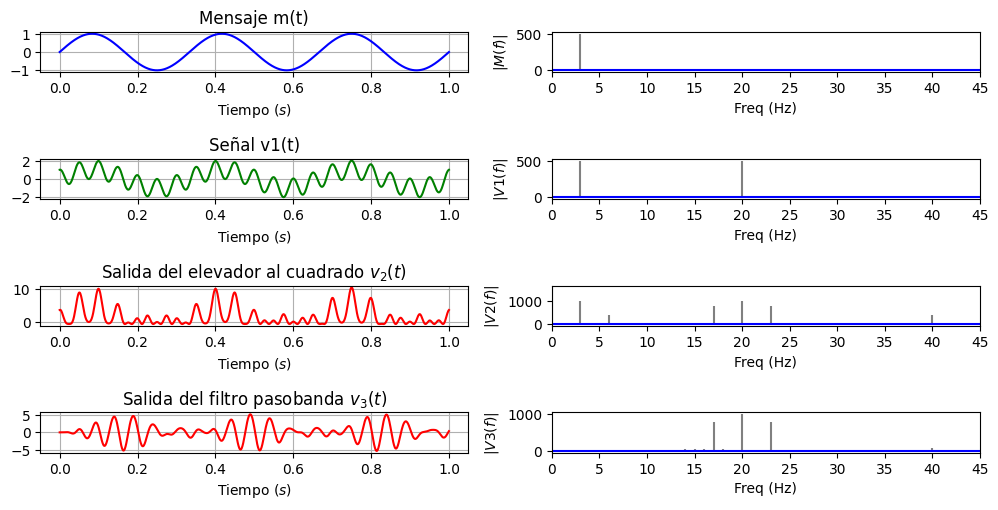

In [ ]:
import numpy as np
from numpy.fft import fft,ifft
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter, freqz

# Definir parámetros de la señal
Ac = 1  # Amplitud de la portadora
Am = 1  # Amplitud del mensaje
ka = 0.8  # Índice de modulación
fc = 20  # Frecuencia de la portadora en Hz
fm= 3     # Frecuencia del mensaje en Hz

# Definir el mensaje m(t)
t = np.linspace(0, 1, 1000)  # Tiempo de 0 a 1 segundo
m = Am*np.sin(2 * np.pi * fm * t)   #señal de mensaje
v1 = Ac*np.cos(2 * np.pi * fc * t) + m # Señal de entrada

# Hallamos su espectro
V1=fft(v1)
M=fft(m)

N=len(V1)
n=np.arange(N)
Ts=1/1000
Epoca=N*Ts
freq=n/Epoca

#Ahora hallamos v2, la salida del dispositivo square law modulator
a1=2
a2=1.6
v2=a1*v1+a2*v1**2
V2=fft(v2)

def butter_bandpass(lowcut, highcut, fs, order=5):
    return butter(order, [lowcut, highcut], fs=fs, btype='band', analog=False)

def butter_bandpass_filter(data, lowcut, highcut, fs, order=5):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    y = lfilter(b, a, data)
    return y

order=6
fs=1000 #frecuencia de muestro
v3 = butter_bandpass_filter(v2, 15, 35,  fs, order)
V3=fft(v3)

#Graficos
plt.figure(figsize=(10, 6))

plt.subplot(5, 2, 1)
plt.plot(t, m, 'b')
plt.title('Mensaje m(t)')
plt.xlabel('Tiempo ($s$)')
plt.grid(True)

plt.subplot(5, 2, 2)
plt.stem(freq, np.abs(M), linefmt='grey', markerfmt=" ", bottom=1.1, basefmt="-b")
#plt.stem(freq, np.abs(M), 'b', markerfmt=" ", basefmt="-b")
plt.xlabel('Freq (Hz)')
plt.ylabel('$|M(f)|$')
plt.xlim(0, 45)

plt.subplot(5, 2, 3)
plt.plot(t, v1, 'g')
plt.title('Señal v1(t)')
plt.xlabel('Tiempo ($s$)')
plt.grid(True)

plt.subplot(5, 2, 4)
plt.stem(freq, np.abs(V1), linefmt='grey', markerfmt=" ", bottom=1.1, basefmt="-b")
#plt.stem(freq, np.abs(M), 'b', markerfmt=" ", basefmt="-b")
plt.xlabel('Freq (Hz)')
plt.ylabel('$|V1(f)|$')
plt.xlim(0, 45)

plt.subplot(5, 2, 5)
plt.plot(t, v2, 'r')
plt.title('Salida del elevador al cuadrado $v_2(t)$')
plt.xlabel('Tiempo ($s$)')
plt.grid(True)

plt.subplot(5, 2, 6)
plt.stem(freq, np.abs(V2), linefmt='grey', markerfmt=" ", bottom=1.1, basefmt="-b")
#plt.stem(freq, np.abs(M), 'b', markerfmt=" ", basefmt="-b")
plt.xlabel('Freq (Hz)')
plt.ylabel('$|V2(f)|$')
plt.xlim(0, 45)

plt.subplot(5, 2, 7)
plt.plot(t, v3, 'r')
plt.title('Salida del filtro pasobanda $v_3(t)$')
plt.xlabel('Tiempo ($s$)')
plt.grid(True)

plt.subplot(5, 2, 8)
plt.stem(freq, np.abs(V3), linefmt='grey', markerfmt=" ", bottom=1.1, basefmt="-b")
#plt.stem(freq, np.abs(M), 'b', markerfmt=" ", basefmt="-b")
plt.xlabel('Freq (Hz)')
plt.ylabel('$|V3(f)|$')
plt.xlim(0, 45)

plt.tight_layout()
plt.show()


---
## **Ejercicio 2.7**
**- Demodulación de señales AM**

<div>
<img src='https://drive.google.com/uc?id=17ioaJzU4OlZ3hLyta_hoSevcsVvVC7wy' width="700"/>
</div>

### **Solución analítica**
La salida del primer bloque puede ser descrita como:
\begin{equation}
v_1(t) = (A_c)^2 [1+k_am(t)]^2 \cos^2(2 \pi f_c t)
\end{equation}
\begin{equation}
v_1(t) = \frac{A_c^2}{2} [1+2k_am(t) + m^2(t)] [1+\cos(4\pi f_c t)]
\end{equation}
que como vemos en la ecuación, en $v_1(t)$ tenemos componentes en:
(INTEPRETACIÓN DEL ESPECTRO)

*   En Bandabase, tenemos una señal DC, una señal proporcial a $m(t)$ y el cuadrado de $m(t)$.
*   Alrededor de $2f_c$, tenemos otra vez las mismas señales que en Bandabase.

En la simulación se muestra la figura del espectro de esta señal.

Cuando pasamos por el ``Filtro Pasabajas'', nos quedamos solo con el espectro alrededor de frecuencia '0'. Nos interesa justamente la componente del mensaje en Bandabase. Por tanto, basta con que elijamos una frecencia de corte para nuestro filtro de  $2W<f<2f_c -2W$. La señal a la salida del filtro será:

\begin{equation}
v_2 = \frac{A_c^2}{2}[1 + k_am(t)]^2,
\end{equation}

y así, luego, la salida del ``Extractor de Raiz Cuadrada'' es:

\begin{equation}
v_3(t) = \frac{A_c}{\sqrt{2}}[1+k_am(t)]
\end{equation}

donde vemos la presencia del mensaje montado sobre un señal DC. Si desacoplamos la DC (capacitor), ya tendríamos el mensaje recuperado.



### **Simulación**

En el siguiente bloque de código simularemos el proceso, donde se pueden verificar las soluciones analíticas graficadas.

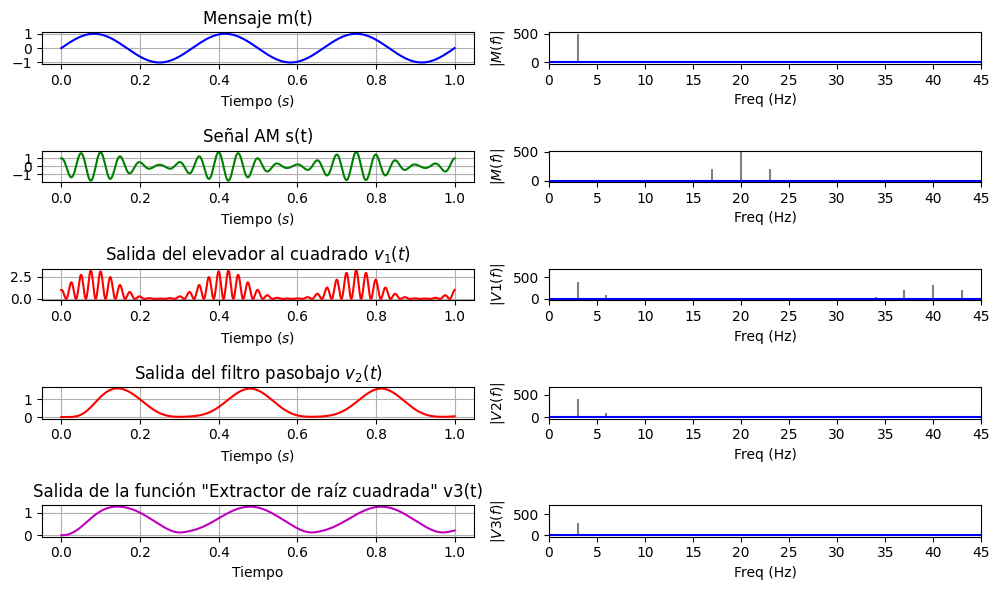

In [ ]:
import numpy as np
from numpy.fft import fft,ifft
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter, freqz


# Definir parámetros de la señal
Ac = 1  # Amplitud de la portadora
Am = 1  # Amplitud del mensaje
ka = 0.8  # Índice de modulación
fc = 20  # Frecuencia de la portadora en Hz
fm= 3     # Frecuencia del mensaje en Hz

# Definir el mensaje m(t)
t = np.linspace(0, 1, 1000)  # Tiempo de 0 a 1 segundo
m = Am*np.sin(2 * np.pi * fm * t)  # Señal de mensaje (ejemplo)

# Hallamos su espectro
M=fft(m)

N=len(M)
n=np.arange(N)
Ts=1/1000
Epoca=N*Ts
freq=n/Epoca


# Señal modulada AM DSB-FC que entra al sistema
s = Ac * (1 + ka * m) * np.cos(2 * np.pi * fc * t)
# Espectro
S=fft(s)

#Aplicamos el diagrama a la señal recibida

# "Elevador al cuadrado"
v1 = s**2
V1=fft(v1)

# "Filtro pasobajo"

def butter_lowpass(cutoff, fs, order=5):
    return butter(order, cutoff, fs=fs, btype='low', analog=False)

def butter_lowpass_filter(data, cutoff, fs, order=5):
    b, a = butter_lowpass(cutoff, fs, order=order)
    y = lfilter(b, a, data)
    return y


#  Implementación de un filtro pasabajos simple (promedio móvil)
#def low_pass_filter(signal, window_size):
    #return np.convolve(signal, np.ones(window_size)/window_size, mode='same')
order=6
cutoff=10 #Hz
fs=1000 #frecuencia de muestro
v2 = butter_lowpass_filter(v1, cutoff, fs, order)
V2=fft(v2)

# "Extractor de raíz cuadrada"
v3 = np.sqrt(v2)
V3=fft(v3)

#Graficos
plt.figure(figsize=(10, 6))

plt.subplot(5, 2, 1)
plt.plot(t, m, 'b')
plt.title('Mensaje m(t)')
plt.xlabel('Tiempo ($s$)')
plt.grid(True)

plt.subplot(5, 2, 2)
plt.stem(freq, np.abs(M), linefmt='grey', markerfmt=" ", bottom=1.1, basefmt="-b")
#plt.stem(freq, np.abs(M), 'b', markerfmt=" ", basefmt="-b")
plt.xlabel('Freq (Hz)')
plt.ylabel('$|M(f)|$')
plt.xlim(0, 45)

plt.subplot(5, 2, 3)
plt.plot(t, s, 'g')
plt.title('Señal AM s(t)')
plt.xlabel('Tiempo ($s$)')
plt.grid(True)

plt.subplot(5, 2, 4)
plt.stem(freq, np.abs(S), linefmt='grey', markerfmt=" ", bottom=1.1, basefmt="-b")
#plt.stem(freq, np.abs(M), 'b', markerfmt=" ", basefmt="-b")
plt.xlabel('Freq (Hz)')
plt.ylabel('$|M(f)|$')
plt.xlim(0, 45)

plt.subplot(5, 2, 5)
plt.plot(t, v1, 'r')
plt.title('Salida del elevador al cuadrado $v_1(t)$')
plt.xlabel('Tiempo ($s$)')
plt.grid(True)

plt.subplot(5, 2, 6)
plt.stem(freq, np.abs(V1), linefmt='grey', markerfmt=" ", bottom=1.1, basefmt="-b")
#plt.stem(freq, np.abs(M), 'b', markerfmt=" ", basefmt="-b")
plt.xlabel('Freq (Hz)')
plt.ylabel('$|V1(f)|$')
plt.xlim(0, 45)

plt.subplot(5, 2, 7)
plt.plot(t, v2, 'r')
plt.title('Salida del filtro pasobajo $v_2(t)$')
plt.xlabel('Tiempo ($s$)')
plt.grid(True)

plt.subplot(5, 2, 8)
plt.stem(freq, np.abs(V2), linefmt='grey', markerfmt=" ", bottom=1.1, basefmt="-b")
#plt.stem(freq, np.abs(M), 'b', markerfmt=" ", basefmt="-b")
plt.xlabel('Freq (Hz)')
plt.ylabel('$|V2(f)|$')
plt.xlim(0, 45)

plt.subplot(5, 2, 9)
plt.plot(t, v3, 'm')
plt.title('Salida de la función "Extractor de raíz cuadrada" v3(t)')
plt.xlabel('Tiempo')
plt.grid(True)

plt.subplot(5, 2, 10)
plt.stem(freq, np.abs(V3), linefmt='grey', markerfmt=" ", bottom=1.1, basefmt="-b")
#plt.stem(freq, np.abs(M), 'b', markerfmt=" ", basefmt="-b")
plt.xlabel('Freq (Hz)')
plt.ylabel('$|V3(f)|$')
plt.xlim(0, 45)

plt.tight_layout()
plt.show()


---
## **Ejercicio 2.9**
**- Modulación AM**
<div>
<img src='https://drive.google.com/uc?id=17mMSiW9AtEqrZvze3KIv7WertyAQuhF6' width="700"/>
</div>

### **Solución analítica**
Atendiendo el esquema, la señales $s_1(t)$ y $s_2(t)$ son:

\begin{equation}
s_1(t) = A_c [1 + k_a m(t)] \cos(2 \pi f_c t),
\end{equation}
y
\begin{equation}
s_2(t) = A_c [1 - k_a m(t)] \cos(2 \pi f_c t).
\end{equation}

Así entonces
\begin{equation}
s(t) = s_1(t)-s_2(t)= 2 k_a m(t) \cos(2 \pi f_c t),
\end{equation}

que como vemos corresponde a una señal DSB-SC, como indicaba el enunciado.





### **Simulación**

En el siguiente bloque de código simularemos el proceso, donde se pueden verificar los resultados mediante las gráficas de las soluciones analíticas.

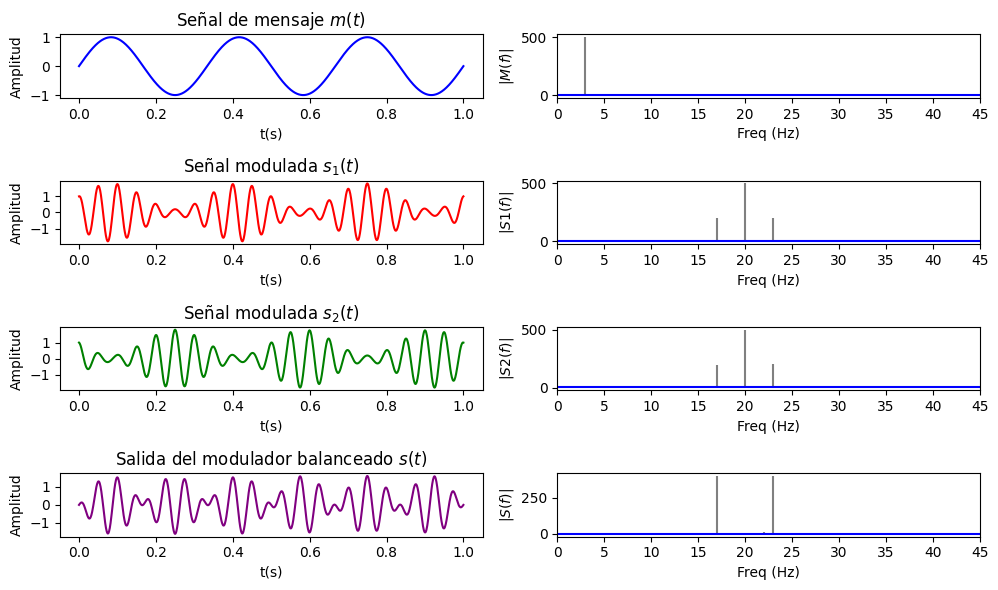

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft, ifft

# Definición de parámetros
Ac = 1  # Amplitud de la portadora
fc = 20  # Frecuencia de la portadora
fm = 3  # Frecuencia de la señal de mensaje
t = np.linspace(0, 1, 1000)  # Vector de tiempo
k_a = 0.8  # Índice de modulación

# Señal de mensaje m(t)
m = np.sin(2 * np.pi * fm * t)

# Señales moduladas s1(t) y s2(t)
s1 = Ac * (1 + k_a*m) * np.cos(2 * np.pi * fc * t)
s2 = Ac * (1 - k_a*m) * np.cos(2 * np.pi * fc * t)

# Salida del modulador balanceado s(t)
s = s1 - s2

# Gráficos de las señales
plt.figure(figsize=(10, 6))

M=fft(m)

N=len(M)
n=np.arange(N)
Ts=1/1000
Epoca=N*Ts
freq=n/Epoca

plt.subplot(4, 2, 1)
plt.plot(t, m, 'b')
plt.title('Señal de mensaje $m(t)$')
plt.xlabel('t(s)')
plt.ylabel('Amplitud')

plt.subplot(4, 2, 2)
plt.stem(freq, np.abs(M), linefmt='grey', markerfmt=" ", bottom=1.1, basefmt="-b")
#plt.stem(freq, np.abs(M), 'b', markerfmt=" ", basefmt="-b")
plt.xlabel('Freq (Hz)')
plt.ylabel('$|M(f)|$')
plt.xlim(0, 45)

plt.subplot(4, 2, 3)
plt.plot(t, s1, 'r')
plt.title('Señal modulada $s_1(t)$')
plt.xlabel('t(s)')
plt.ylabel('Amplitud')

S1=fft(s1)
plt.subplot(4, 2, 4 )
plt.stem(freq, np.abs(S1), linefmt='grey', markerfmt=" ", bottom=1.1, basefmt="-b")
#plt.stem(freq, np.abs(M), 'b', markerfmt=" ", basefmt="-b")
plt.xlabel('Freq (Hz)')
plt.ylabel('$|S1(f)|$')
plt.xlim(0, 45)

plt.subplot(4, 2, 5)
plt.plot(t, s2, 'g')
plt.title('Señal modulada $s_2(t)$')
plt.xlabel('t(s)')
plt.ylabel('Amplitud')

S2=fft(s2)
plt.subplot(4, 2, 6 )
plt.stem(freq, np.abs(S2), linefmt='grey', markerfmt=" ", bottom=1.1, basefmt="-b")
#plt.stem(freq, np.abs(M), 'b', markerfmt=" ", basefmt="-b")
plt.xlabel('Freq (Hz)')
plt.ylabel('$|S2(f)|$')
plt.xlim(0, 45)

plt.subplot(4, 2, 7)
plt.plot(t, s, 'purple')
plt.title('Salida del modulador balanceado $s(t)$')
plt.xlabel('t(s)')
plt.ylabel('Amplitud')

S=fft(s)
plt.subplot(4, 2, 8 )
plt.stem(freq, np.abs(S), linefmt='grey', markerfmt=" ", bottom=1.1, basefmt="-b")
#plt.stem(freq, np.abs(M), 'b', markerfmt=" ", basefmt="-b")
plt.xlabel('Freq (Hz)')
plt.ylabel('$|S(f)|$')
plt.xlim(0, 45)

plt.tight_layout()
plt.show()


---
## **Ejercicio 2.19 (Dev)**
**- Modulación AM y aplicaciones: Criptografía**
<div>
<img src='https://drive.google.com/uc?id=17nM09EoNeYAsvU3W92DY6wOPWz6JC-jM' width="700"/>
</div>


### **Solución analítica 2**
El flujo de procesamiento de la señal, según el enunciado, es como sigue:

1. **Modulador Producto**

\begin{equation}
v_1(t) = m(t) \cos(2 \pi f_c t).
\end{equation}

2. **Filtro Pasoalto**

\begin{equation}
v_2(t) = \frac{1}{2}m^+(t) e^{j2\pi f_c}.
\end{equation}

3. **Modulador Producto**

\begin{equation}
v_3(t) = v_2(t) \cos(2 \pi (f_{b}+f_{c})t).
\end{equation}

\begin{equation}
v_3(t) =  \frac{1}{2} m^+(t) [\cos(2 \pi f_c t)+ j\sin(2 \pi f_c t)] \cos(2 \pi (f_{b}+f_{c})t).
\end{equation}

\begin{equation}
v_3(t) =  \frac{1}{4}m^+(t) [\cos(2 \pi (f_c -f_c-f_b)t + \cos(2 \pi (f_c + f_{b}+f_{c})t)] + \frac{1}{4}jm^+(t) [\sin(2 \pi (f_c -f_c-f_b)t + \sin(2 \pi (f_c + f_{b}+f_{c})t)].
\end{equation}

\begin{equation}
v_3(t) =  \frac{1}{4}m^+(t) [\cos(2 \pi f_bt) + \cos(2 \pi (2f_c + f_b)t)] + \frac{1}{4}jm^+(t) [\sin(2 \pi f_bt) + \sin(2 \pi (2f_c + f_b)t)].
\end{equation}

4. **Filtro Pasobajo**
\begin{equation}
v_4(t) =  \frac{1}{4}m^+(t) \cos(2 \pi f_bt) + \frac{1}{4}jm^+(t) \sin(2 \pi f_bt) = \frac{1}{4}m(t) \cos(2 \pi f_bt) + \frac{1}{4}j \hat m(t) \cos(2 \pi f_bt) + \frac{1}{4}jm(t) \sin(2 \pi f_bt) - \frac{1}{4} \hat m(t) \sin(2 \pi f_bt)
\end{equation}

---
### **Solución analítica**
El flujo de procesamiento de la señal, según el enunciado, es como sigue:

1. **Modulador Producto**

\begin{equation}
v_1(t) = m(t) \cos(2 \pi f_c t).
\end{equation}

2. **Filtro Pasoalto**

\begin{equation}
v_2(t) = \frac{1}{2}m^+(t) \cos(2 \pi f_c t).
\end{equation}

3. **Modulador Producto**

\begin{equation}
v_3(t) = v_2(t) \cos(2 \pi (f_{b}+f_{c})t).
\end{equation}

\begin{equation}
v_3(t) =  \frac{1}{2} m^+(t) \cos(2 \pi f_c t) \cos(2 \pi (f_{b}+f_{c})t).
\end{equation}

\begin{equation}
v_3(t) =  \frac{1}{4}m^+(t) [\cos(2 \pi (f_c -f_c-f_b)t + \cos(2 \pi (f_c + f_{b}+f_{c})t)].
\end{equation}

\begin{equation}
v_3(t) =  \frac{1}{4}m^+(t) [\cos(2 \pi f_bt) + \cos(2 \pi (2f_c + f_b)t)].
\end{equation}

4. **Filtro Pasobajo**
\begin{equation}
v_4(t) =  \frac{1}{4}m^+(t) \cos(2 \pi f_bt)=  \frac{1}{4}m(t) \cos(2 \pi f_bt) +\frac{1}{4}j\hat m(t) \cos(2 \pi f_bt).
\end{equation}

---
Del mismo modo, la salida del segundo modulador producto está dada por:

\begin{equation}
v_3(t) = v_2(t)\cos[2 \pi (f_c + f_b)t].
\end{equation}

Para represetar el espectro de la señal $m(t)$, podemos representarla en función de sus analíticas. Así,
\begin{equation}
m(t) = \frac{1}{2}[m^+(t) + m^-(t)],
\end{equation}

con espectros de las anañíticas $^+$ y $^-$ como sigue:

\begin{equation}
M_+(f) = \begin{cases}
      2M(f), & \text{si } f > 0 \\
      0, & \text{si } f < 0
\end{cases}
\end{equation}

\begin{equation}
M_-(f) = \begin{cases}
      0, & \text{si } f > 0 \\
      2M(f), & \text{si } f < 0
\end{cases}
\end{equation}

La salida del ***criptógrafo***, atendiendo su espectro, podemos escribir como:
\begin{equation}
s(t)=\frac{1}{8}m^+(t)e^{-j2\pi f_bt}+\frac{1}{8}m^-e^{j2\pi f_bt}
\end{equation}

\begin{equation}
s(t)=\frac{1}{8}[m(t)+j\hat{m}(t)]e^{-2j\pi f_bt}+\frac{1}{8}[m(t)-j\hat{m}(t)]e^{j2\pi f_bt}
\end{equation}

\begin{equation}
s(t)=\frac{1}{4}m(t)\cos(2\pi f_bt)+\frac{1}{4}\hat{m} \sin(2\pi f_bt).
\end{equation}

Mostramos los espectros en la simulación presentada a continuación.

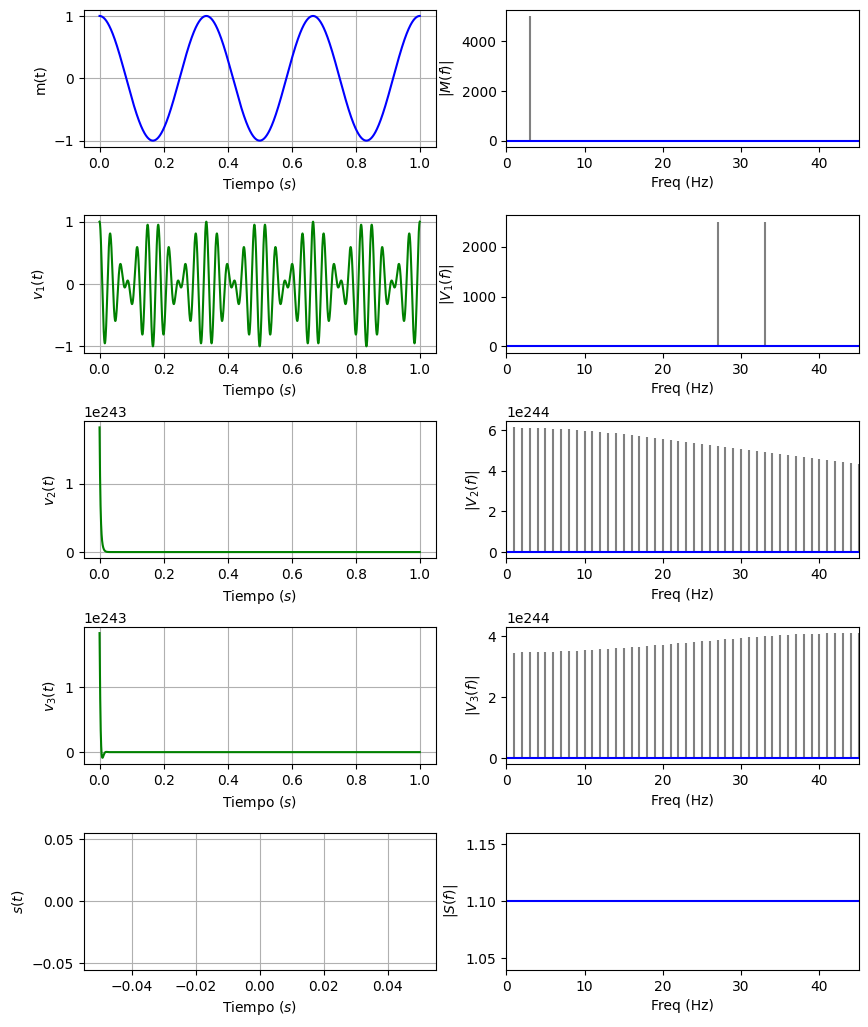

In [ ]:
import numpy as np
from numpy.fft import fft,ifft
import matplotlib.pyplot as plt
from scipy import signal

# Definir parámetros de la señal
Am1 = 1  # Amplitud del mensaje
Am2 = 0  # Amplitud del mensaje
Am3 = 0  # Amplitud del mensaje

ka = 0.8  # Índice de modulación
fm1= 3     # Frecuencia del mensaje en Hz
fm2= 5     # Frecuencia del mensaje en Hz
fm3= 7     # Frecuencia del mensaje en Hz
fm4=11

# Definir el mensaje m(t)
t = np.linspace(0, 1, 10000)  # Tiempo de 0 a 1 segundo
m1= Am1*np.cos(2 * np.pi * fm1 * t)
m2= Am2*np.cos(2 * np.pi * fm2 * t)
m3= Am3*np.cos(2 * np.pi * fm3 * t)

m = m1+m2+m3  # Señal de mensaje (ejemplo)

plt.figure(figsize=(10, 6))

plt.subplot(5, 2, 1)
plt.plot(t, m, 'b')
plt.ylabel('m(t)')
plt.xlabel('Tiempo ($s$)')
plt.grid(True)

M=fft(m)

N=len(M)
n=np.arange(N)
Ts=1/10000
Epoca=N*Ts
freq=n/Epoca

plt.subplot(5, 2, 2)
plt.stem(freq, np.abs(M), linefmt='grey', markerfmt=" ", bottom=1.1, basefmt="-b")
plt.xlabel('Freq (Hz)')
plt.ylabel('$|M(f)|$')
plt.xlim(0, 45)

#Modulador Produnto 1
Ac = 1  # Amplitud de la portadora
fc = 30  # Frecuencia de la portadora en Hz

v1 = Ac * m * np.cos(2 * np.pi * fc * t)

plt.subplot(5, 2, 3)
plt.plot(t, v1, 'g')
plt.ylabel('$v_1(t)$')
plt.xlabel('Tiempo ($s$)')
plt.grid(True)

V1=fft(v1)
plt.subplot(5, 2, 4)
plt.stem(freq, np.abs(V1), linefmt='grey', markerfmt=" ", bottom=1.1, basefmt="-b")
plt.xlabel('Freq (Hz)')
plt.ylabel('$|V_1(f)|$')
plt.xlim(0, 45)

#La salida del filtro paso alto
# Filtro Paso Alto
b_high, a_high = signal.butter(10, 0.004, 'high')
v2 = signal.filtfilt(b_high, a_high, v1)

plt.subplot(5, 2, 5)
plt.plot(t, v2, 'g')
plt.ylabel('$v_2(t)$')
plt.xlabel('Tiempo ($s$)')
plt.grid(True)

V2=fft(v2)
plt.subplot(5, 2, 6)
plt.stem(freq, np.abs(V2), linefmt='grey', markerfmt=" ", bottom=1.1, basefmt="-b")
plt.xlabel('Freq (Hz)')
plt.ylabel('$|V_2(f)|$')
plt.xlim(0, 45)

#Modulador Produnto 2
Ac = 1  # Amplitud de la portadora
f3 = fc+fm4 # Frecuencia de la portadora del msegundo modulado rproducto en Hz

v3 = Ac * v2 * np.cos(2 * np.pi * f3 * t)

plt.subplot(5, 2, 7)
plt.plot(t, v3, 'g')
plt.ylabel('$v_3(t)$')
plt.xlabel('Tiempo ($s$)')
plt.grid(True)

V3=fft(v3)
plt.subplot(5, 2, 8)
plt.stem(freq, np.abs(V3), linefmt='grey', markerfmt=" ", bottom=1.1, basefmt="-b")
plt.xlabel('Freq (Hz)')
plt.ylabel('$|V_3(f)|$')
plt.xlim(0, 45)

# Filtro Pasabajo
b_low, a_low = signal.butter(10, 15*Ts*2, 'low')
s = signal.filtfilt(b_low, a_low, v3)#Aplicamos filto pasabajos

plt.subplot(5, 2, 9)
plt.plot(t, s, 'g')
plt.ylabel('$s(t)$')
plt.xlabel('Tiempo ($s$)')
plt.grid(True)

S=fft(s)
plt.subplot(5, 2, 10)
plt.stem(freq, np.abs(S), linefmt='grey', markerfmt=" ", bottom=1.1, basefmt="-b")
plt.xlabel('Freq (Hz)')
plt.ylabel('$|S(f)|$')
plt.xlim(0, 45)

plt.subplots_adjust(left=None, bottom=.4, right=None, top=2, wspace=None, hspace=0.5)
##plt.tight_layout()
plt.show()

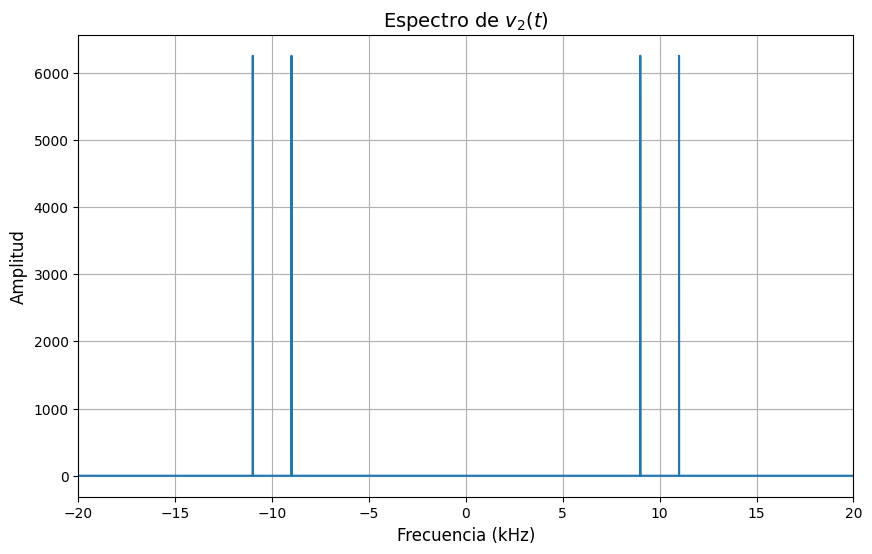

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Definimos las frecuencias para la señal
fc = 10e3  # Frecuencia de la portadora (10 kHz)
fs = 50e3  # Frecuencia de muestreo (50 kHz)
t = np.linspace(0, 1, int(fs), endpoint=False)  # Tiempo de 1 segundo

# Espectro de la señal moduladora m(t)
fm = 1e3  # Frecuencia de la señal moduladora (1 kHz)
m_t = np.cos(2 * np.pi * fm * t)  # Señal moduladora

# Envolvente analítica
m_plus_t = m_t + 1j * np.imag(np.fft.ifft(1j * np.fft.fft(m_t)))  # Envolvente analítica

# v2(t): Producto de m^+(t) con la portadora
v2_t = (1 / 2) * np.real(m_plus_t * np.cos(2 * np.pi * fc * t))

# Espectro de v2(t)
v2_f = np.fft.fftshift(np.fft.fft(v2_t))
frequencies = np.fft.fftshift(np.fft.fftfreq(len(v2_t), 1 / fs))

# Gráfico del espectro
plt.figure(figsize=(10, 6))
plt.plot(frequencies / 1e3, np.abs(v2_f))
plt.title("Espectro de $v_2(t)$", fontsize=14)
plt.xlabel("Frecuencia (kHz)", fontsize=12)
plt.ylabel("Amplitud", fontsize=12)
plt.grid(True)
plt.xlim(-20, 20)  # Mostramos frecuencias relevantes
plt.show()


In [ ]:
# Graficamos el espectro completo centrado en cero para verificar que las frecuencias negativas sean 0.

plt.figure(figsize=(10, 6))
plt.plot(frequencies / 1e3, np.abs(m_plus_f_full))  # Magnitud del espectro completo
plt.title("Espectro de la señal analítica $m^+(t)$ con frecuencias negativas", fontsize=14)
plt.xlabel("Frecuencia (kHz)", fontsize=12)
plt.ylabel("Amplitud", fontsize=12)
plt.grid(True)
plt.xlim(-15, 15)  # Incluimos frecuencias negativas y positivas
plt.show()



NameError: name 'm_plus_f_full' is not defined

<Figure size 1000x600 with 0 Axes>